## Individuell inlämningsuppgift – Deep Learning

# Marcus Bäckström


In [1]:
# Grundläggande bibliotek
import time

import os
from PIL import Image

import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Train/validation-split och utvärdering
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# TensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(42)
train_dir = "Data/train"
test_dir = "Data/test"

# Funktions

In [2]:
# Load images from folder and give it a class and put it in y based on folder title.

def load_images_from_folder(dir, image_size=(48, 48), max_per_class = None ):

    X = []
    y = []
    class_names = sorted(os.listdir(dir))

    for label, class_name in enumerate(class_names):
        class_path = os.path.join(dir, class_name)
        if not os.path.isdir(class_path):
            continue

        images = os.listdir(class_path)

        if  max_per_class is not None:
            images = images[:max_per_class]

        for img_file in images:
            img_path = os.path.join(class_path, img_file)

            try:
                img = Image.open(img_path).convert("L") # Convert to grayscale in case they are not grayscale.
                img = img.resize(image_size)
                X.append(np.array(img))
                y.append(label)
            except:
                pass    
    


    return  np.array(X), np.array(y), class_names

In [3]:
# Plot images taken randomly with n_images with how many.

def plot_image_grid(X,y, class_names, n_images=25, random_state=42, afigsize=(12, 12) ):

    rng = np.random.default_rng(random_state)
    indices = rng.choice(len(X), size=n_images, replace=False)

    grid_size = int(np.ceil(np.sqrt(n_images) ) )

    plt.figure(figsize=afigsize)

    for plot_index, image_index in enumerate(indices):
        
        plt.subplot(grid_size, grid_size, plot_index + 1)

        plt.imshow(X[image_index], cmap="gray")

        plt.title(class_names[y[image_index] ], fontsize=9 )

        plt.axis("off")

    plt.tight_layout()
    plt.show()

In [4]:
# Save History
def save_history(history, history_name ="model_name"): 
    with open(f"Histories/{history_name}.json", "w") as f:
        json.dump(history.history, f)

In [5]:
# Load History

class FakeHistory:
    def __init__(self, history_dict):
        self.history = history_dict



def load_history(history_name="model_name"):
    with open(f"Histories/{history_name}.json", "r") as f:
        history_data = json.load(f)

    loaded_history = FakeHistory(history_data)

    return loaded_history

In [6]:
# Plot Loss and Accuracy by epoch´s

def plot_history(history, title="", afigsize=(12, 4) ):
    history_df = pd.DataFrame(history.history)

    epochs = range(1, len(history_df) + 1)

    plt.figure(figsize=afigsize)

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["loss"], label="Training Loss")
    plt.plot(epochs, history_df["val_loss"], label="Validation Loss")

    plt.xlabel("Epok")
    plt.ylabel("Loss")
    plt.title("Loss")

    plt.ylim(0,2.5)
    plt.xlim(1, len(history_df) )

    plt.legend()

    plt.suptitle(title)
    
    plt.figure(figsize=afigsize )

    plt.subplot(1, 2, 1)
    plt.plot(epochs, history_df["accuracy"], label="Training Accuracy")
    plt.plot(epochs, history_df["val_accuracy"], label="Validation Accuracy")

    plt.xlabel("Epok")
    plt.ylabel("Accuracy")
    plt.title("Accuracy")

    plt.ylim(0,1)
    plt.xlim(1, len(history_df) )

    plt.legend()

    plt.suptitle(title)

    plt.tight_layout()
    plt.show()

In [7]:
# Build model´s with adjustable params

def build_custom_models(
        input_shape = (48, 48, 1), 
        l2_unit = 0.0, blocks = 1,
        convs_per_block = 1, 
        filters =[32, 64, 128], 
        kernel_size = (3,3), 
        conv_dropout = 0,
        dense_dropout = 0,
        dense_units = 128,
        learning_rate = 0.001 ):

    model = keras.Sequential()
    model.add(layers.Input(shape=(input_shape) ) )

    # L2 regulaisering.
    kernel_regularizer = (keras.regularizers.l2(l2_unit) if l2_unit > 0 else None)

    for b in range(blocks):

        for c in range(convs_per_block):

            model.add(
                layers.Conv2D(
                    filters=filters[b],
                    kernel_size=kernel_size,
                    activation="relu",
                    padding="same",
                    kernel_regularizer=kernel_regularizer
                )
            )
        model.add(layers.MaxPooling2D(pool_size=(2 , 2)))

        if conv_dropout > 0 :
            model.add(layers.Dropout(conv_dropout))

    model.add(layers.Flatten())

    model.add(
        layers.Dense(
            dense_units,
            activation="relu",
            kernel_regularizer=kernel_regularizer
        )
    )

    if dense_dropout > 0:
        model.add(layers.Dropout(dense_dropout))

    model.add(layers.Dense(10, activation="softmax"))

    model.compile(
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate),
        loss = keras.losses.SparseCategoricalCrossentropy(),
        metrics = ["accuracy"]
    )


    return model



In [8]:
# Make Early Stopping Callback

def build_early_stopping_callback(early_patience=3, early_monitor="val_loss"):
   
    callbacks = []
    callbacks.append(
        keras.callbacks.EarlyStopping(
            monitor=early_monitor,
            patience=early_patience,
            restore_best_weights=True,
            mode="min"
        )

    )

    return callbacks

In [9]:
# Load single image

def load_prepare_image_for_model(img_path):

    img = Image.open(img_path)

    if img.mode != "L":
        img = img.convert("L")

    img = img.resize((48, 48))

    img_array = np.array(img).astype("float32")

    # if it´s already been normalized it wont be divided by 255 again. 
    if img_array.max() > 1.0:
        img_array = img_array / 255.0

    # Add channel if there is none. Turning (48, 48) too (48, 48, 1)
    if img_array.ndim == 2:
        img_array = img_array[..., np.newaxis]

    # Add Batch if there is none. turning (48, 48, 1) too (1, 48, 48, 1)
    # if img_array.ndim == 3:
    #     img_array = np.expand_dims(img_array, axis=0)

    return img_array

# 1. Förstå datan

## Early peek at the Data

In [10]:
class_names_train = sorted(os.listdir(train_dir))
print(f"Train Klasser : {class_names_train}")
class_names_test = sorted(os.listdir(test_dir))
print(f"Test Klasser : {class_names_test}")

Train Klasser : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Test Klasser : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [11]:
class_distribution_train = pd.DataFrame({
    "train_class_name": class_names_train,
    "count": [len(os.listdir(os.path.join(train_dir, cls))) for cls in class_names_train]
})

class_distribution_test = pd.DataFrame({
    "test_class_name": class_names_test,
    "count": [len(os.listdir(os.path.join(test_dir, cls))) for cls in class_names_test]
})

display(class_distribution_train)
display(class_distribution_test)

,train_class_name,count
0,angry,3995
1,disgust,436
2,fear,4097
3,happy,7215
4,neutral,4965
5,sad,4830
6,surprise,3171


,test_class_name,count
0,angry,958
1,disgust,111
2,fear,1024
3,happy,1774
4,neutral,1233
5,sad,1247
6,surprise,831


In [12]:
print("Totalt antal träningsbilder:", class_distribution_train["count"].sum())
print("Totalt antal testbilder:", class_distribution_test["count"].sum())


Totalt antal träningsbilder: 28709
Totalt antal testbilder: 7178


# 2. Förbered datan

## Load image: 

### Small batch

In [13]:

X_train_full, y_train_full, class_names = load_images_from_folder(
    train_dir, 
    max_per_class=300
)

print(f"X_train_full Shape : {X_train_full.shape}")
print(f"y_train_full Shape : {y_train_full.shape}")
print(f"Class Names : {class_names}")

X_train_full Shape : (2100, 48, 48)
y_train_full Shape : (2100,)
Class Names : ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


## Check Loaded Images

In [14]:
class_counts = pd.Series(y_train_full).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

,class_id,class_name,count
0,0,angry,300
1,1,disgust,300
2,2,fear,300
3,3,happy,300
4,4,neutral,300
5,5,sad,300
6,6,surprise,300


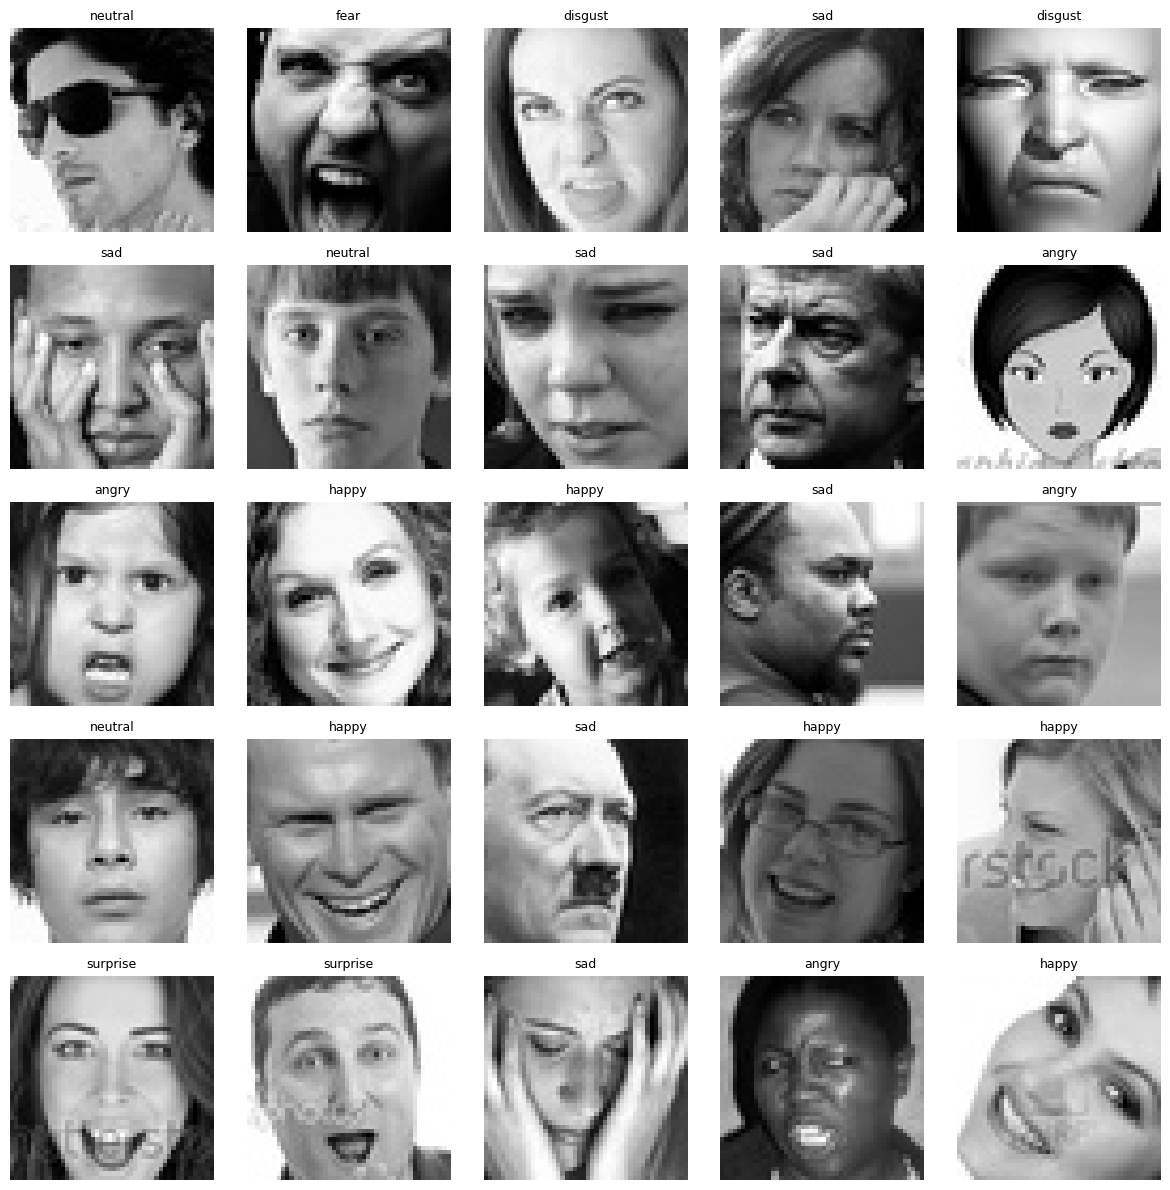

In [15]:
plot_image_grid(
    X=X_train_full,
    y=y_train_full,
    class_names=class_names,
    n_images=25
)

In [16]:
print("Minsta pixel värde : ", X_train_full.min())
print("Största pixel värde : ", X_train_full.max())

Minsta pixel värde :  0
Största pixel värde :  255


## Train Val 

In [17]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    random_state=42,
    test_size=0.10,
    stratify=y_train_full
)

print(f"X_train Shape :  {X_train.shape}")
print(f"y_train Shape :  {y_train.shape}")
print(f"X_val Shape :  {X_val.shape}")
print(f"y_val Shape :  {y_val.shape}")


X_train Shape :  (1890, 48, 48)
y_train Shape :  (1890,)
X_val Shape :  (210, 48, 48)
y_val Shape :  (210,)


In [18]:
class_counts = pd.Series(y_val).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

,class_id,class_name,count
0,0,angry,30
1,1,disgust,30
2,2,fear,30
3,3,happy,30
4,4,neutral,30
5,5,sad,30
6,6,surprise,30


In [19]:
X_test, y_test, test_class_names = load_images_from_folder(
    dir=test_dir,
    max_per_class=100)

In [20]:
class_counts = pd.Series(y_test).value_counts().sort_index()

class_distribution = pd.DataFrame({
    "class_id": class_counts.index,
    "class_name": [test_class_names[i] for i in class_counts.index],
    "count": class_counts.values
})

class_distribution

,class_id,class_name,count
0,0,angry,100
1,1,disgust,100
2,2,fear,100
3,3,happy,100
4,4,neutral,100
5,5,sad,100
6,6,surprise,100


## Format/Scale data

In [21]:
X_train = X_train.astype("float32") / 255.0
X_val = X_val.astype("float32") / 255.0

In [22]:
X_test = X_test.astype("float32") / 255.0

In [23]:
# add channel as cnn model need 3 vector, X, Y, Z.
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]

print("X_train Shape efter kanal-dimension", X_train.shape)
print("X_val Shape efter kanal-dimension", X_val.shape)


X_train Shape efter kanal-dimension (1890, 48, 48, 1)
X_val Shape efter kanal-dimension (210, 48, 48, 1)


In [24]:
# add channel as cnn model need 3 vector, X, Y, Z.
X_test = X_test[..., np.newaxis]

print("X_test Shape efter kanal-dimension", X_test.shape)


X_test Shape efter kanal-dimension (700, 48, 48, 1)


# 3. Bygg en modell

## Begin Models

### Baseline Model

In [25]:
baseline_model_funktion = build_custom_models(blocks=2, dense_units=64)
baseline_model_funktion.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       589,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 609,354 (2.32 MB)

 Trainable params: 609,354 (2.32 MB)

 Non-trainable params: 0 (0.00 B)

# 4. Träna modellen

### Träningen är kommenterad eftersom modellen redan tränats en gång.
### För att göra notebooken snabbare och reproducerbar laddas den sparade modellen och historiken istället.


In [26]:
# commented out to save time not having to train each time i rerun the code. will use loaded history and loaded model instead of training it from scratch

# baseline_history_funktion = baseline_model_funktion.fit(
#     X_train,
#     y_train,
#     validation_data=(X_val, y_val),
#     epochs = 10,
#     batch_size=32
# )



# Save Model & History

In [27]:
# baseline_model_funktion.save("Models/baseline_model_funktion.keras")

In [28]:
loaded_baseline_model_funktion = keras.models.load_model("Models/baseline_model_funktion.keras")

### Made with help from AI as i asked how to save and load history i dont need to do fit every time

In [29]:
# save_history(baseline_history_funktion, history_name="baseline_history_funktion")

In [30]:
loaded_baseline_history_funktion = load_history(history_name="baseline_history_funktion")

# #

## Plot baseline

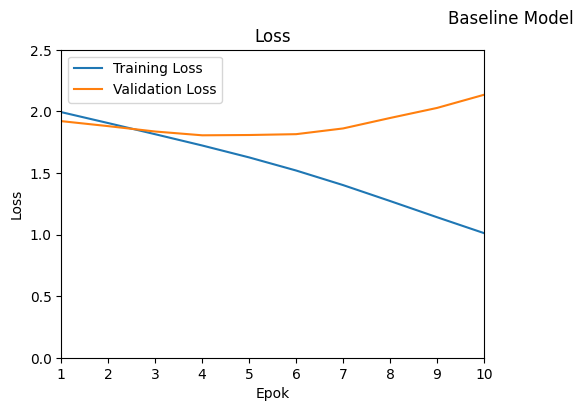

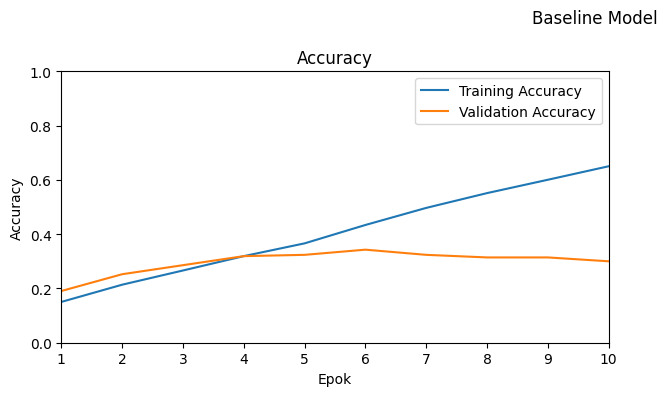

In [31]:
plot_history(loaded_baseline_history_funktion,title="Baseline Model")

## Analys av Baseline-modellen:

I loss grafen ser vi att training loss minskar medan validation loss ökar över epoker.
Detta betyder att modellen överfittar.

Detta betyder att modellen lär sig detaljer i träningsdatan men generaliserar inte bra på ny data.
Om modellen skulle ge´s bilder som inte är med i träning´s datan skulle prestera sämre än den gör på tränings datan.  

# 5. Utvärdera modellen

## test data

### Baseline model

In [32]:
test_loss, test_accuracy = loaded_baseline_model_funktion.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss : {test_loss:.4f}")
print(f"Test Accuracy : {test_accuracy:.4f}")

Test Loss : 2.1170
Test Accuracy : 0.3171


#### Test Analysis

Baseline‑modellen hade låg validation accuracy och hög validation loss under träningen, vilket tyder på överfitting. Därför är testresultatet (loss 2.1170 och accuracy 0.3171) helt rimligt och ligger i linje med valideringsresultaten. Modellen generaliserar alltså dåligt till ny data, vilket är förväntat för en enkel baseline‑CNN.



# 6. Gör prediktioner på ny data

In [33]:
image_folder = "Images/"
image_name = "Skärmbild 2025-08-06 180720 cropped.png"

## Picture before loading and converting.

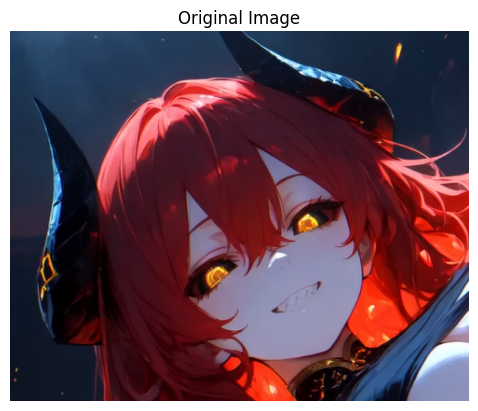

In [34]:
img = Image.open(f"{image_folder}{image_name}")
plt.imshow(img)
plt.title("Original Image")
plt.axis("off")
plt.show()

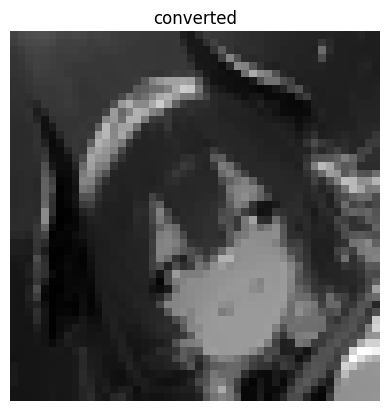

In [35]:
loaded_image = load_prepare_image_for_model(img_path=f"{image_folder}{image_name}")

plt.imshow(loaded_image,cmap="gray")
plt.title("converted")
plt.axis("off")
plt.show()

# Keras models expect input with a batch dimension: (batch, height, width, channels).
# A single image has shape (48,48,1), so we add a batch dimension to make it (1,48,48,1).
if loaded_image.ndim == 3:
    loaded_image_batched = np.expand_dims(loaded_image, axis=0)

## Prediction using baseline model and new image.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step


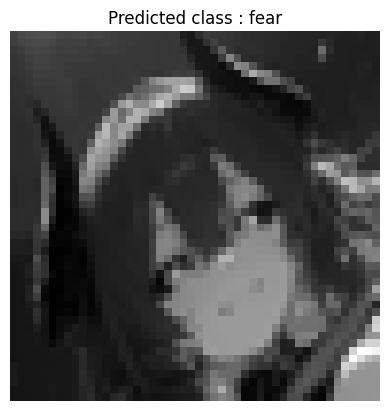

Top 3 predicted classes:
fear: 98.52%
sad: 0.72%
neutral: 0.50%


In [39]:
proba = loaded_baseline_model_funktion.predict(loaded_image_batched)[0]

pred = np.argmax(proba)

_ = plt.imshow(loaded_image, cmap="gray")
plt.title(f"Predicted class : {class_names[pred]}")
plt.axis("off")
plt.show()


top3_idx = np.argsort(proba)[-3:][::-1]

print("Top 3 predicted classes:")
for idx in top3_idx:
    print(f"{class_names[idx]}: {proba[idx]*100:.2f}%")

# Discarded code.

Spara det bara ifall jag behöver titta på det senare. 

In [37]:
# without using funktion.

# baseline_model = keras.Sequential([

#     layers.Input(shape=(48, 48, 1)),

#     layers.Conv2D(
#         filters=32,
#         kernel_size=(3, 3),
#         activation="relu",
#         padding="same"
#     ),

#     layers.MaxPooling2D(2, 2),

    
#     layers.Conv2D(
#         filters=64,
#         kernel_size=(3, 3),
#         activation="relu",
#         padding="same"
#     ),

#     layers.MaxPooling2D(2, 2),

#     layers.Flatten(),

#     layers.Dense(64, activation="relu"),


#     layers.Dense(10, activation="softmax")

# ])

# baseline_model.summary()

# baseline_model.compile(
#     optimizer=keras.optimizers.Adam(learning_rate=0.001),
#     loss=keras.losses.SparseCategoricalCrossentropy(),
#     metrics=["accuracy"]
# )

# baseline_history = baseline_model.fit(
#     X_train,
#     y_train,
#     validation_data=(X_val, y_val),
#     epochs=5,
#     batch_size=32
# )

# baseline_model.save("Models/baseline_model.keras")

# loaded_baseline_model = keras.models.load_model("Models/baseline_model.keras")

# with open("Histories/baseline_history.json", "w") as f:
#     json.dump(baseline_history.history, f)

# with open("Histories/baseline_history.json", "r") as f:
#     baseline_history_data = json.load(f)

# class FakeHistory:
#     def __init__(self, history_dict):
#         self.history = history_dict

# loaded_baseline_history = FakeHistory(baseline_history_data)